In [1]:
# ---- Core -------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Preprocessing ----------------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA

# ---- Model selection --------------------------------------------------------
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_val_score, cross_validate,
    GridSearchCV, RandomizedSearchCV,
)

# ---- Models -----------------------------------------------------------------
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier, IsolationForest,
)
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor
import xgboost as xgb
         
# ---- Metrics ----------------------------------------------------------------
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
    precision_recall_curve, silhouette_score,
)
from sklearn.inspection import permutation_importance

# ---- Config -----------------------------------------------------------------
RANDOM_STATE = 42          # set everywhere so results are reproducible
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# ---- Paths (edit to match your repo) ----------------------------------------
HDB_PATH   = "/Users/cheerupdimbo/Documents/ds-sprint-july/ds-sprint-july/projects/projects1_hdb/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv"
SECOM_PATH = "/Users/cheerupdimbo/Documents/ds-sprint-july/ds-sprint-july/projects/projects2_secom/uci-secom.csv"


In [2]:
df = pd.read_csv(HDB_PATH)
print(df.shape)
print("\n")
print(df.dtypes)

(234672, 11)


month                      str
town                       str
flat_type                  str
block                      str
street_name                str
storey_range               str
floor_area_sqm         float64
flat_model                 str
lease_commence_date      int64
remaining_lease            str
resale_price           float64
dtype: object


In [3]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 234672 entries, 0 to 234671
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                234672 non-null  str    
 1   town                 234672 non-null  str    
 2   flat_type            234672 non-null  str    
 3   block                234672 non-null  str    
 4   street_name          234672 non-null  str    
 5   storey_range         234672 non-null  str    
 6   floor_area_sqm       234672 non-null  float64
 7   flat_model           234672 non-null  str    
 8   lease_commence_date  234672 non-null  int64  
 9   remaining_lease      234672 non-null  str    
 10  resale_price         234672 non-null  float64
dtypes: float64(2), int64(1), str(8)
memory usage: 19.7 MB


In [5]:
df.isnull().sum().sort_values(ascending= True)

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

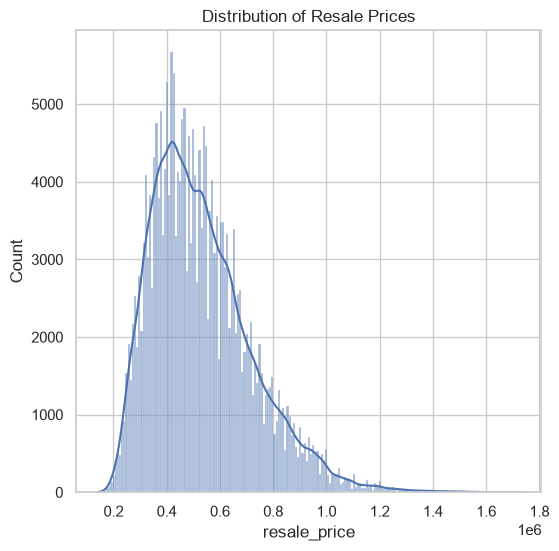

In [6]:
plt.figure(figsize=(6,6))
sns.histplot(
    df['resale_price'],
    kde=True,
)
plt.title('Distribution of Resale Prices')
plt.show()

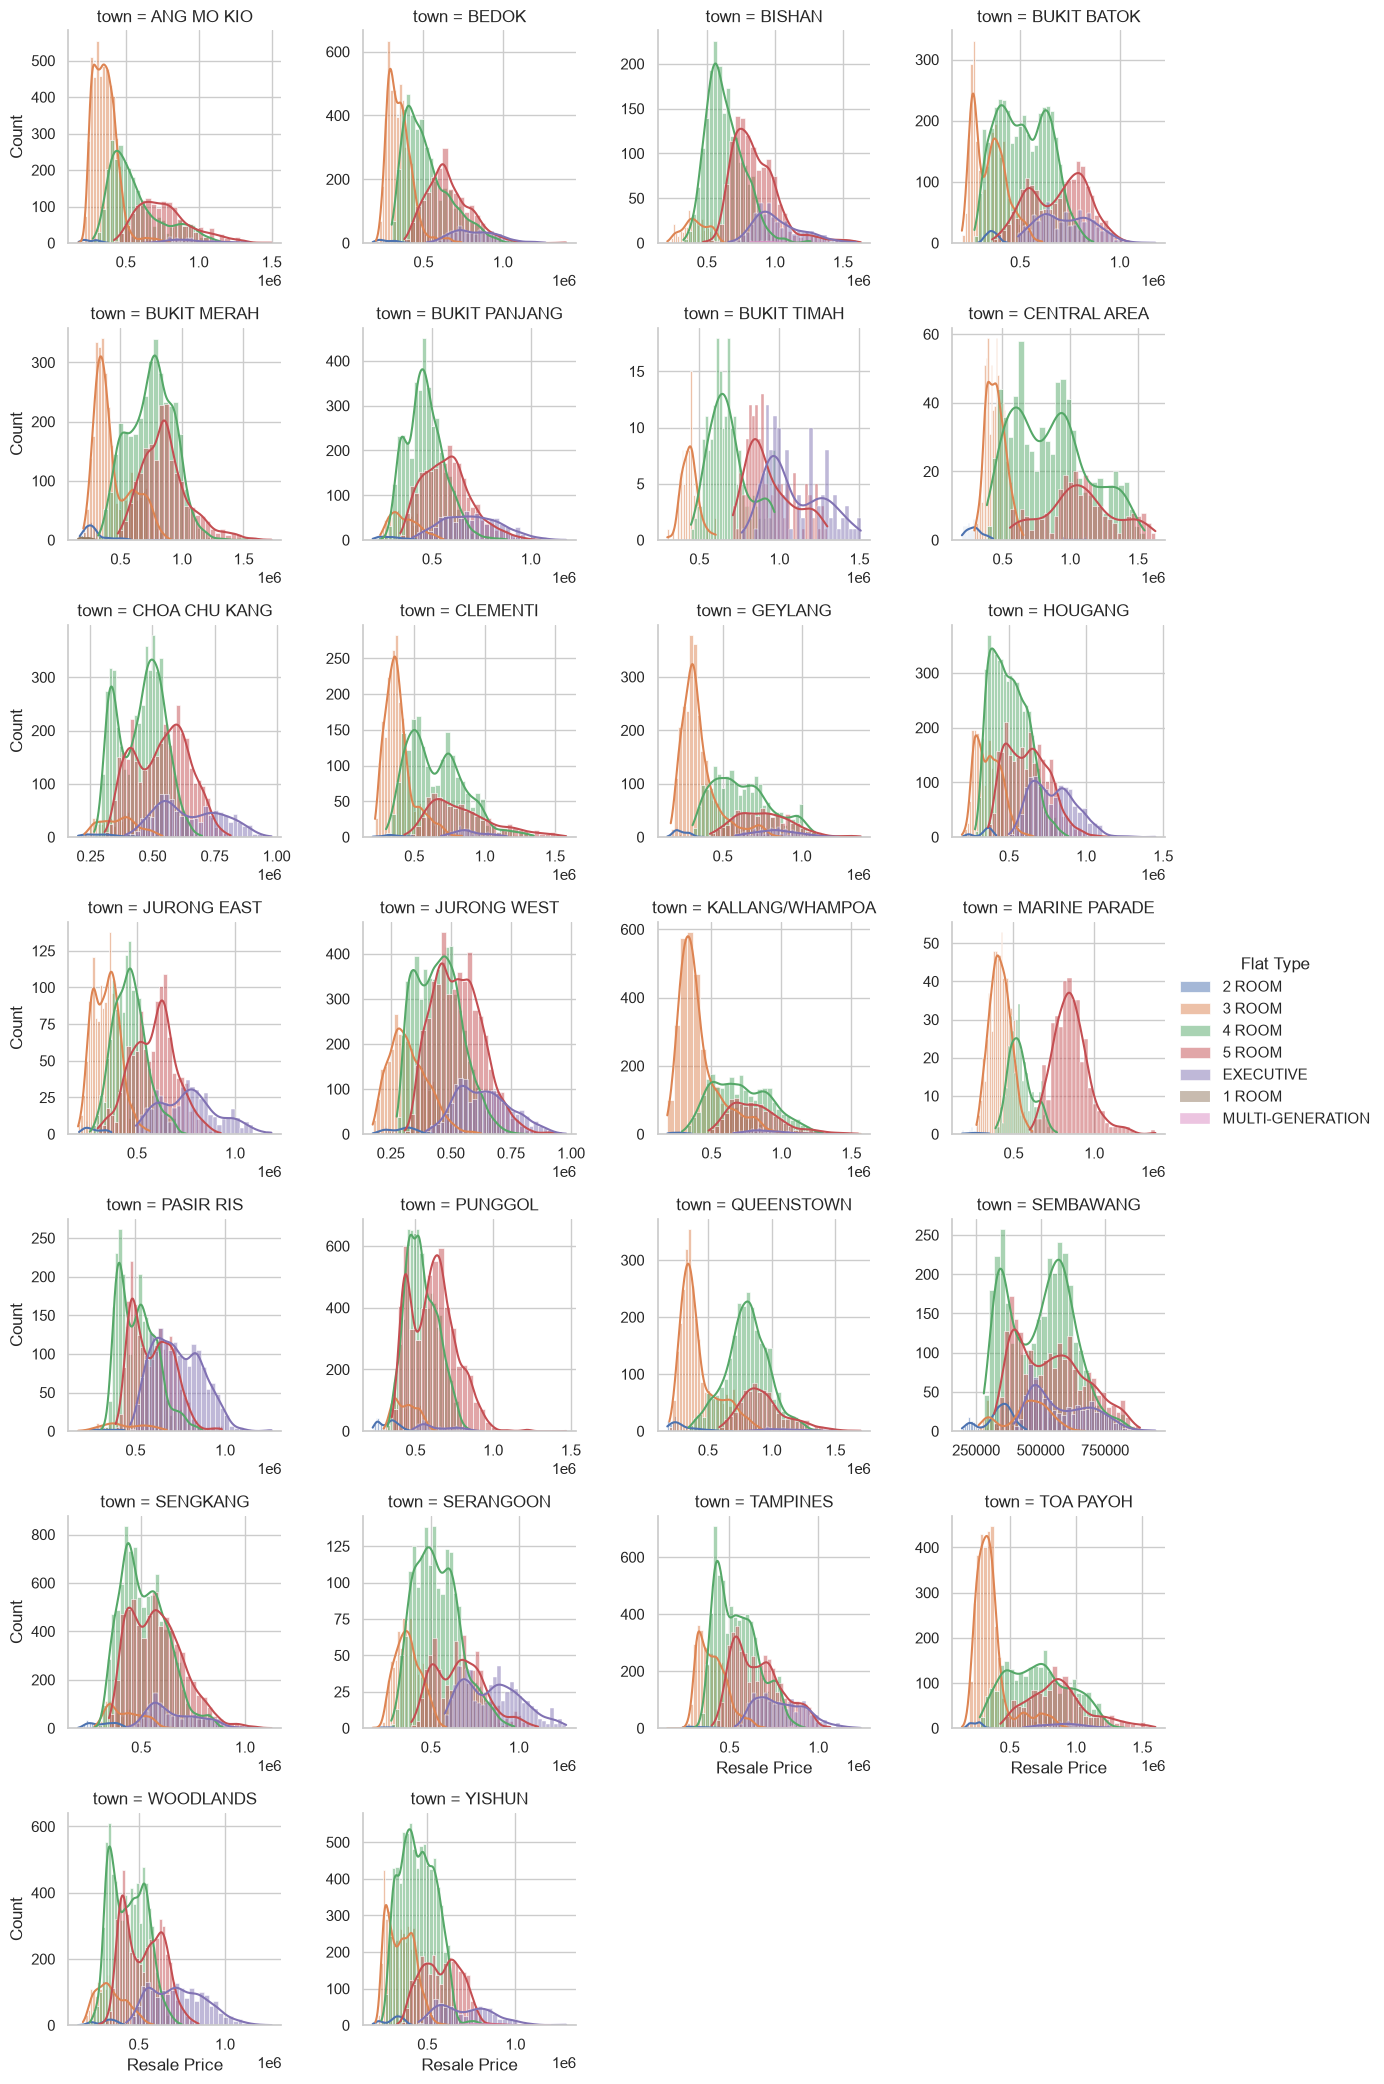

In [7]:
g = sns.FacetGrid(df, col= 'town', col_wrap=4, height=3, sharey= False, sharex= False, hue= 'flat_type')
g.map(sns.histplot, 'resale_price', bins = 30, kde=True)
g.add_legend(title='Flat Type')
g.set_axis_labels('Resale Price', 'Count')
plt.show()

In [8]:
df["month"] = pd.to_datetime(df["month"])
df["sale_year"] = df["month"].dt.year
df["flat_age"] = df["sale_year"] - df["lease_commence_date"]
storey_bounds = df["storey_range"].str.extract(r"(\d+)\s+TO\s+(\d+)").astype(float)
df["storey_mid"] = storey_bounds.mean(axis=1)

df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,sale_year,flat_age,storey_mid
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,2017,38,11.0
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,2017,39,2.0
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,2017,37,2.0
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,2017,37,5.0
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,2017,37,2.0


In [9]:
TARGET = 'resale_price'
num_features = ["floor_area_sqm", "flat_age", "storey_mid", "sale_year"]
cat_features = ["town", "flat_type", "flat_model"]

X = df[num_features + cat_features]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'train={X_train.shape} \ntest={X_test.shape}')

train=(187737, 7) 
test=(46935, 7)


In [10]:
numeric_pipe = Pipeline([
    ("scale", StandardScaler())
])

categorial_pipe = Pipeline([
    ("onehot", OneHotEncoder())
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_features),
    ('cat', categorial_pipe, cat_features)
])

baseline = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge(alpha=0.1))
])

cv = KFold(
    n_splits=5, 
    shuffle=True, 
    random_state=RANDOM_STATE
    )

In [11]:
rmse_cv=-cross_val_score(
    baseline, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error"
)
print(f"Ridge baseline RMSE: {rmse_cv.mean():,.0f}(+/-{rmse_cv.std():,.0f})")
print(f"Ridge baseline RMSE: {rmse_cv.mean()}(a/-{rmse_cv.std()})")

Ridge baseline RMSE: 69,305(+/-310)
Ridge baseline RMSE: 69305.13180343318(a/-309.6739998982135)


In [12]:
candidates={
    "Ridge": Ridge(
        alpha=0.1
        ),
    "rf": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
        ),
    "xgb": xgb.XGBRegressor(
        n_estimators = 400,
        learning_rate=0.1,
        max_depth = 6,
        random_state = RANDOM_STATE,
        n_jobs=-1            
    )
}

for name, model in candidates.items():
    pipe=Pipeline([
        ("prep",
        preprocessor),
        ("model",
         model)
    ])
    scores = -cross_val_score(
        pipe, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error"
    )
    print(f"{name:6s}\nRMSE {scores.mean():>10,.0f} (+/- {scores.std():,.0f})")

Ridge 
RMSE     69,305 (+/- 310)
rf    
RMSE     39,235 (+/- 282)
xgb   
RMSE     39,900 (+/- 212)


In [13]:
param_grids = {
    "Ridge": {
        "model__alpha": [0.01, 0.1, 1.0, 10.0]
    },
    "rf": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 8, 12]
    },
    "xgb": {
        "model__max_depth": [4, 6, 8],
        "model__learning_rate": [0.05, 0.1],
        "model__n_estimators": [300, 600],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    }
}

results = {}

for name, model in candidates.items():
    search = GridSearchCV(
        Pipeline([
            ("prep", preprocessor),
            ("model", model)
        ]),
        param_grids[name],
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        verbose=1,
        refit=True
    )
    search.fit(X_train, y_train)
    print(f'{name} CV RMSE: {-search.best_score_:.0f}')
    results[name] = {
        "search" : search,
        "best_model" : search.best_estimator_,
        "best_params" : search.best_params_
        }


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Ridge CV RMSE: 69305
Fitting 5 folds for each of 6 candidates, totalling 30 fits
rf CV RMSE: 39190
Fitting 5 folds for each of 48 candidates, totalling 240 fits
xgb CV RMSE: 36017


In [14]:
final_model = results["xgb"]["best_model"]
y_pred = final_model.predict(X_test)

In [17]:
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"MAE. : {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"MAE. : {r2_score(y_test, y_pred):,.0f}")

RMSE : 36,020
MAE. : 25,796
MAE. : 1


<function matplotlib.pyplot.show(close=None, block=None)>

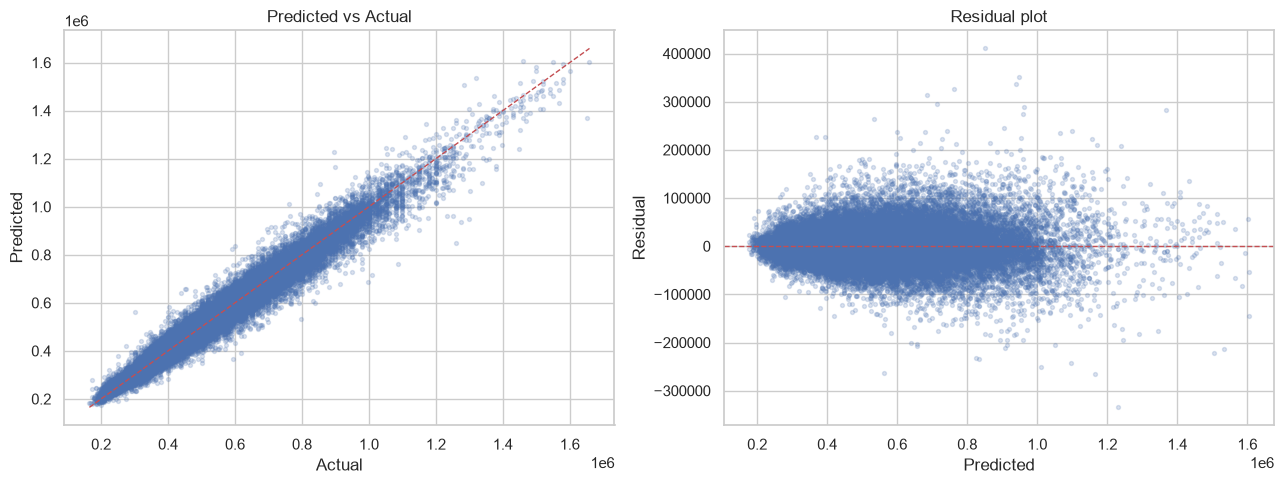

In [18]:
fig, axes = plt.subplots(1,2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha = 0.2, s=8)
lims = (y_test.min(), y_test.max())
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set(xlabel="Actual", ylabel="Predicted", title="Predicted vs Actual")

residuals = y_test-y_pred
axes[1].scatter(y_pred, residuals, alpha=0.2, s=8)
axes[1].axhline(0, color="r", ls="--", lw=1)
axes[1].set(xlabel="Predicted", ylabel="Residual", title="Residual plot")
plt.tight_layout(); plt.show

In [21]:
new_data = pd.DataFrame({
    "town": ["ANG MO KIO"],
    "flat_type": ["4 ROOM"],
    "storey_range": ["10 TO 12"],
    "floor_area_sqm": [95.0],
    "flat_model": ["Improved"],
    "lease_commence_date": [1990],
})

# Recreate the same engineered features used during training
new_data["sale_year"] = 2026  # or pd.to_datetime("2026-06").year, whatever your "current" sale year is
new_data["flat_age"] = new_data["sale_year"] - new_data["lease_commence_date"]

storey_bounds = new_data["storey_range"].str.extract(r"(\d+)\s+TO\s+(\d+)").astype(float)
new_data["storey_mid"] = storey_bounds.mean(axis=1)

predicted_price = final_model.predict(new_data)
print(predicted_price)

[649886.9]


In [24]:
perm = permutation_importance(
    final_model, 
    X_test, 
    y_test, 
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

imp = (pd.Series(
    perm.importances_mean,
    index = X_test.columns
    ).sort_values(ascending=False)
)

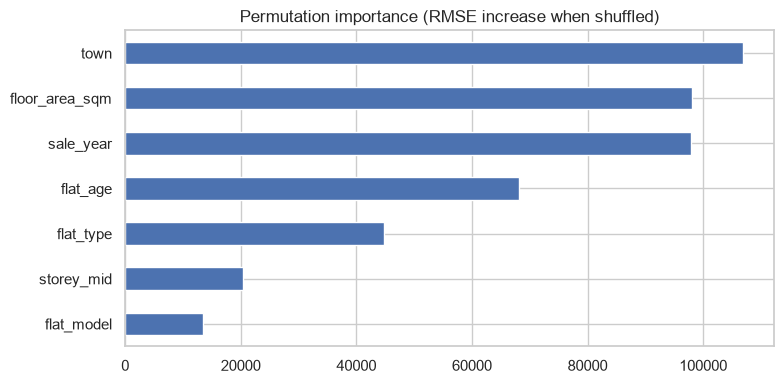

In [25]:
plt.figure(
    figsize=(
        8,
        4
        )
)

imp.head(10).plot(kind="barh").invert_yaxis()
plt.title("Permutation importance (RMSE increase when shuffled)")
plt.tight_layout(); plt.show()